In [61]:
# Used Bike Prices – Feature Engineering & Exploratory Data Analysis

## Project Overview

This project analyzes a dataset of used bikes to understand the factors that influence their resale prices.

The project focuses on data cleaning, feature engineering, exploratory data analysis, visualization, and correlation analysis.

### Objectives Clean and preprocess the used bike dataset Handle missing and inconsistent values Perform feature engineering Analyze relationships between bike characteristics and price Identify patterns and trends using visualizations Extract meaningful insights from the data# Importing the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

SyntaxError: invalid syntax (1789202072.py, line 5)

In [4]:
# Loading the used bike dataset

df = pd.read_csv("bikes.csv")

In [5]:
# Displaying the first 5 rows of the dataset

df.head()
# Checking the number of rows and columns

df.shape
# Displaying all column names

df.columns
# Checking data types and non-null values

df.info()
# Generating statistical summary of numerical columns

df.describe()
# Checking the number of missing values in each column

df.isnull().sum()
# Checking the number of duplicate rows

df.duplicated().sum()
# Checking the number of unique values in each column

df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7857 entries, 0 to 7856
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   model_name  7857 non-null   object
 1   model_year  7857 non-null   int64 
 2   kms_driven  7857 non-null   object
 3   owner       7857 non-null   object
 4   location    7838 non-null   object
 5   mileage     7846 non-null   object
 6   power       7826 non-null   object
 7   price       7857 non-null   int64 
dtypes: int64(2), object(6)
memory usage: 491.2+ KB


model_name    1724
model_year      36
kms_driven    1801
owner            4
location       561
mileage        117
power          272
price         1627
dtype: int64

In [6]:
# Checking unique values in a categorical column

df['owner'].unique()

array(['first owner', 'third owner', 'second owner',
       'fourth owner or more'], dtype=object)

In [7]:
# Checking missing values and their percentage

missing_values = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_values

,Missing Values,Percentage
model_name,0,0.000000
model_year,0,0.000000
kms_driven,0,0.000000
owner,0,0.000000
location,19,0.241823
mileage,11,0.140003
power,31,0.394553
price,0,0.000000


In [8]:
# Displaying duplicate rows

df[df.duplicated()]
# Removing duplicate rows

df = df.drop_duplicates()
# Checking the number of duplicate rows after removal

df.duplicated().sum()

np.int64(0)

In [9]:
# Selecting numerical columns

numerical_columns = df.select_dtypes(include=np.number).columns

numerical_columns
# Selecting categorical columns

categorical_columns = df.select_dtypes(include='object').columns

categorical_columns
# Checking unique values for each categorical column

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


model_name:
['Bajaj Avenger Cruise 220 2017' 'Royal Enfield Classic 350cc 2016'
 'Hyosung GT250R 2012' ... 'Bajaj Discover 125cc 2009'
 'Bajaj Pulsar 200cc 2011' 'Hero CD Deluxe 100cc 2004']

kms_driven:
['17000 Km' '50000 Km' '14795 Km' ... '66780 Km' '16510 Km' '6407 Km']

owner:
['first owner' 'third owner' 'second owner' 'fourth owner or more']

location:
['hyderabad' 'pondicherry' 'bangalore' 'jaipur' 'chennai' 'ghaziabad'
 'delhi' 'ludhiana' 'jaunpur' 'mumbai' 'chittorgarh' 'thalassery'
 'bathinda' 'gurgaon' 'dehradun' 'pune' 'kukatpally' 'navi mumbai'
 'lucknow' 'siliguri' 'bengaluru' 'rajkot' 'agra' 'bhiwandi' 'patna'
 'udaipur' 'bihar shariff' 'jalandhar' 'vadodara' 'visakhapatnam'
 'thiruvananthapuram' 'ahmedabad' 'bareilly' 'thane' 'kannur' 'surat'
 'kurukshetra' 'moradabad' 'bhagalpur' 'hooghly' 'jhunjhunu' 'kochi'
 'srikakulam' 'jamshedpur' 'hazaribagh' 'noida' 'chandigarh' 'reasi'
 'ambala' 'panchkula' 'balotra' 'sonipat' 'kolkata' 'jind' 'trivandrum'
 'mathura' 'panipat

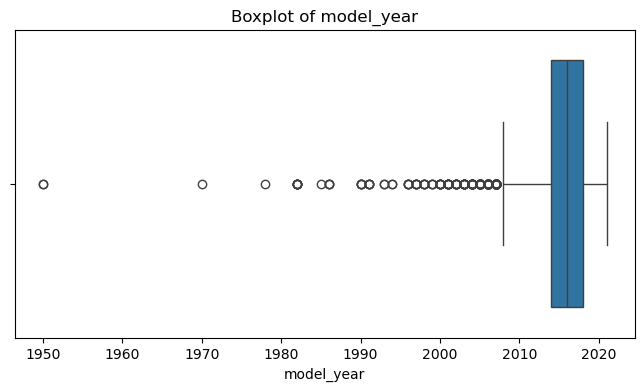

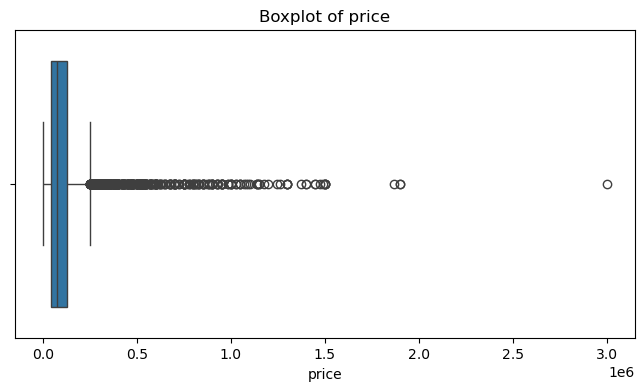

In [10]:
# Checking the data type of each column

df.dtypes
# Checking minimum and maximum values of numerical columns

df[numerical_columns].agg(['min', 'max']).T
# Checking whether numerical columns contain negative values

(df[numerical_columns] < 0).sum()
# Creating boxplots to identify outliers in numerical columns

for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()

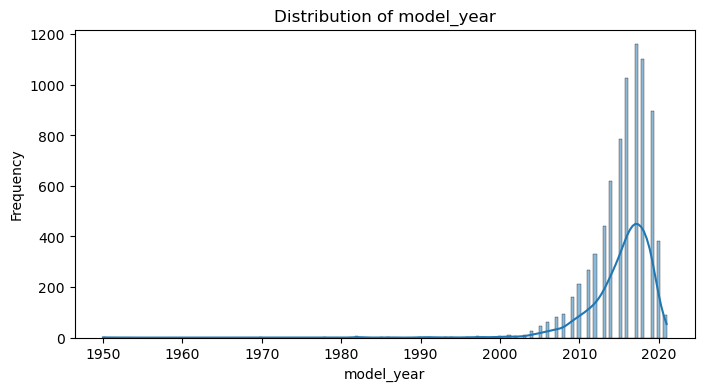

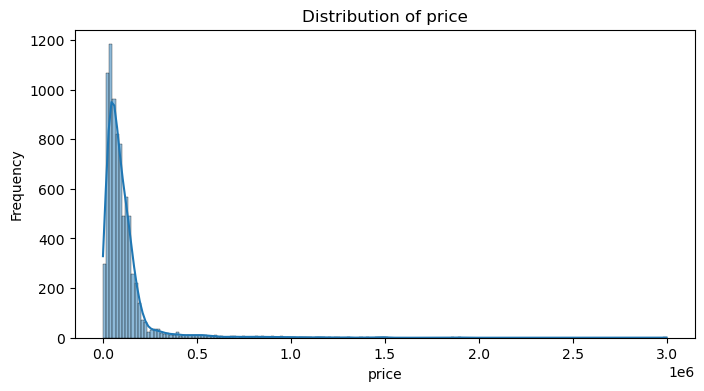

In [11]:
# Plotting distributions of numerical variables

for column in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

In [12]:
# Displaying all column names for feature engineering

df.columns.tolist()

['model_name',
 'model_year',
 'kms_driven',
 'owner',
 'location',
 'mileage',
 'power',
 'price']

In [16]:
# Creating a copy of the dataset before feature engineering

df_fe = df.copy()

# Displaying the first 5 rows

df_fe.head()
# Creating a new feature representing the age of the bike

current_year = 2026

df_fe['Bike_Age'] = current_year - df_fe['model_year']

# Displaying model year and bike age

df_fe[['model_year', 'Bike_Age']].head()

,model_year,Bike_Age
0,2017,9
1,2016,10
2,2012,14
3,2017,9
4,2020,6


In [14]:
# Displaying the exact column names in the dataset

print(df.columns.tolist())

['model_name', 'model_year', 'kms_driven', 'owner', 'location', 'mileage', 'power', 'price']


In [15]:
# Displaying the first 5 rows to understand the dataset structure

df.head()

,model_name,model_year,kms_driven,owner,location,mileage,power,price
0,Bajaj Avenger Cruise 220 2017,2017,17000 Km,first owner,hyderabad,\n\n 35 kmpl,19 bhp,63500
1,Royal Enfield Classic 350cc 2016,2016,50000 Km,first owner,hyderabad,\n\n 35 kmpl,19.80 bhp,115000
2,Hyosung GT250R 2012,2012,14795 Km,first owner,hyderabad,\n\n 30 kmpl,28 bhp,300000
3,Bajaj Dominar 400 ABS 2017,2017,Mileage 28 Kms,first owner,pondicherry,\n\n 28 Kms,34.50 bhp,100000
4,Jawa Perak 330cc 2020,2020,2000 Km,first owner,bangalore,\n\n,30 bhp,197500


In [17]:
# Checking the statistical summary of bike age

df_fe['Bike_Age'].describe()

count    7857.000000
mean       10.632302
std         4.001443
min         5.000000
25%         8.000000
50%        10.000000
75%        12.000000
max        76.000000
Name: Bike_Age, dtype: float64

In [18]:
# Creating categories based on the age of the bike

df_fe['Age_Category'] = pd.cut(
    df_fe['Bike_Age'],
    bins=[-1, 3, 7, 12, np.inf],
    labels=['New', 'Moderate', 'Old', 'Very Old']
)

# Displaying bike age and its category

df_fe[['Bike_Age', 'Age_Category']].head()

,Bike_Age,Age_Category
0,9,Old
1,10,Old
2,14,Very Old
3,9,Old
4,6,Moderate


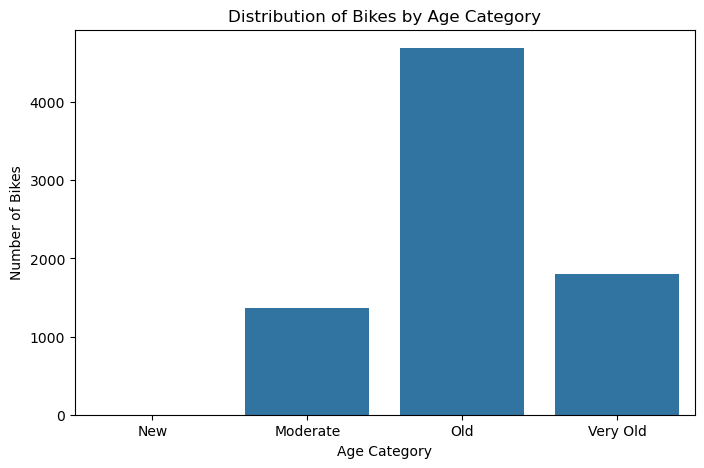

In [19]:
# Counting the number of bikes in each age category

df_fe['Age_Category'].value_counts()
# Visualizing the distribution of bike age categories

plt.figure(figsize=(8, 5))

sns.countplot(x='Age_Category', data=df_fe)

plt.title('Distribution of Bikes by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Number of Bikes')

plt.show()

In [20]:
# Extracting numerical values from the kms_driven column

df_fe['kms_driven'] = (
    df_fe['kms_driven']
    .astype(str)
    .str.extract(r'(\d+(?:\.\d+)?)')[0]
    .astype(float)
)

# Displaying the cleaned kms_driven column

df_fe[['kms_driven']].head()

,kms_driven
0,17000.0
1,50000.0
2,14795.0
3,28.0
4,2000.0


In [21]:
# Checking the data type after cleaning

df_fe['kms_driven'].dtype

dtype('float64')

In [22]:
# Generating statistical summary of kilometers driven

df_fe['kms_driven'].describe()

count       7854.000000
mean       17267.702177
std        26761.689299
min            0.000000
25%          104.000000
50%        11000.000000
75%        25000.000000
max      1000000.000000
Name: kms_driven, dtype: float64

In [23]:
# Extracting numerical values from the mileage column

df_fe['mileage'] = (
    df_fe['mileage']
    .astype(str)
    .str.extract(r'(\d+(?:\.\d+)?)')[0]
    .astype(float)
)

# Displaying the cleaned mileage column

df_fe[['mileage']].head()

,mileage
0,35.0
1,35.0
2,30.0
3,28.0
4,NaN


In [24]:
# Checking the data type of mileage

df_fe['mileage'].dtype
# Checking the statistical summary of mileage

df_fe['mileage'].describe()

count    7083.000000
mean       44.785635
std        16.986112
min         5.000000
25%        35.000000
50%        40.000000
75%        57.000000
max       104.000000
Name: mileage, dtype: float64

In [25]:
# Extracting numerical values from the power column

df_fe['power'] = (
    df_fe['power']
    .astype(str)
    .str.extract(r'(\d+(?:\.\d+)?)')[0]
    .astype(float)
)

# Displaying the cleaned power column

df_fe[['power']].head()

,power
0,19.0
1,19.8
2,28.0
3,34.5
4,30.0


In [26]:
# Checking the data type of power after cleaning

df_fe['power'].dtype
# Generating statistical summary of engine power

df_fe['power'].describe()
# Checking the cleaned numerical features

df_fe[['model_year', 'kms_driven', 'mileage', 'power', 'price']].head()
# Checking data types of the numerical features

df_fe[['model_year', 'kms_driven', 'mileage', 'power', 'price']].dtypes
# Generating statistical summary of numerical features

df_fe[['model_year', 'kms_driven', 'mileage', 'power', 'price']].describe()

,model_year,kms_driven,mileage,power,price
count,7857.000000,7854.000000,7083.000000,7826.000000,7.857000e+03
mean,2015.367698,17267.702177,44.785635,20.765127,1.067913e+05
std,4.001443,26761.689299,16.986112,15.016736,1.389261e+05
min,1950.000000,0.000000,5.000000,6.100000,0.000000e+00
25%,2014.000000,104.000000,35.000000,14.000000,4.200000e+04
50%,2016.000000,11000.000000,40.000000,19.000000,7.500000e+04
75%,2018.000000,25000.000000,57.000000,24.160000,1.250000e+05
max,2021.000000,1000000.000000,104.000000,197.300000,3.000000e+06


In [27]:
# Checking missing values after cleaning the numerical features

df_fe[['model_year', 'kms_driven', 'mileage', 'power', 'price']].isnull().sum()

model_year      0
kms_driven      3
mileage       774
power          31
price           0
dtype: int64

In [28]:
# Creating a new feature representing price relative to kilometers driven

df_fe['Price_Per_KM'] = (
    df_fe['price'] / df_fe['kms_driven'].replace(0, np.nan)
)

# Displaying price, kilometers driven, and price per kilometer

df_fe[['price', 'kms_driven', 'Price_Per_KM']].head()

,price,kms_driven,Price_Per_KM
0,63500,17000.0,3.735294
1,115000,50000.0,2.300000
2,300000,14795.0,20.277121
3,100000,28.0,3571.428571
4,197500,2000.0,98.750000


In [29]:
# Generating statistical summary of Price_Per_KM

df_fe['Price_Per_KM'].describe()
# Creating categories based on kilometers driven

df_fe['Usage_Category'] = pd.cut(
    df_fe['kms_driven'],
    bins=[-1, 20000, 50000, 100000, np.inf],
    labels=['Low Usage', 'Moderate Usage', 'High Usage', 'Very High Usage']
)

# Displaying kilometers driven and usage category

df_fe[['kms_driven', 'Usage_Category']].head()
# Counting the number of bikes in each usage category

df_fe['Usage_Category'].value_counts()
# Displaying all newly created features

df_fe[
    ['Bike_Age', 'Age_Category', 'Price_Per_KM', 'Usage_Category']
].head()
# Checking the updated dataset structure

df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7857 entries, 0 to 7856
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   model_name      7857 non-null   object  
 1   model_year      7857 non-null   int64   
 2   kms_driven      7854 non-null   float64 
 3   owner           7857 non-null   object  
 4   location        7838 non-null   object  
 5   mileage         7083 non-null   float64 
 6   power           7826 non-null   float64 
 7   price           7857 non-null   int64   
 8   Bike_Age        7857 non-null   int64   
 9   Age_Category    7857 non-null   category
 10  Price_Per_KM    7853 non-null   float64 
 11  Usage_Category  7854 non-null   category
dtypes: category(2), float64(4), int64(3), object(3)
memory usage: 629.7+ KB


In [30]:
# Checking missing values in the feature-engineered dataset

df_fe.isnull().sum()
# Calculating the percentage of missing values in each column

missing_values = pd.DataFrame({
    'Missing Values': df_fe.isnull().sum(),
    'Percentage': (df_fe.isnull().sum() / len(df_fe)) * 100
})

missing_values
# Checking missing values in important numerical columns

df_fe[['kms_driven', 'mileage', 'power', 'price']].isnull().sum()
# Filling missing mileage values with the median mileage

df_fe['mileage'] = df_fe['mileage'].fillna(df_fe['mileage'].median())
# Verifying that missing mileage values have been handled

df_fe['mileage'].isnull().sum()
# Checking all remaining missing values after treatment

df_fe.isnull().sum()
# Checking bikes with unusually low kilometers driven

df_fe[df_fe['kms_driven'] < 1000][
    ['model_name', 'model_year', 'kms_driven', 'price']
].head(20)
# Checking for unrealistic bike ages

df_fe[
    (df_fe['Bike_Age'] < 0) | (df_fe['Bike_Age'] > 50)
][['model_name', 'model_year', 'Bike_Age']]

,model_name,model_year,Bike_Age
2211,Bajaj Pulsar NS 200cc 2013,1950,76
3429,Royal Enfield‎ Bullet 350cc 1970,1970,56
4258,Bajaj Pulsar NS 200cc 2013,1950,76


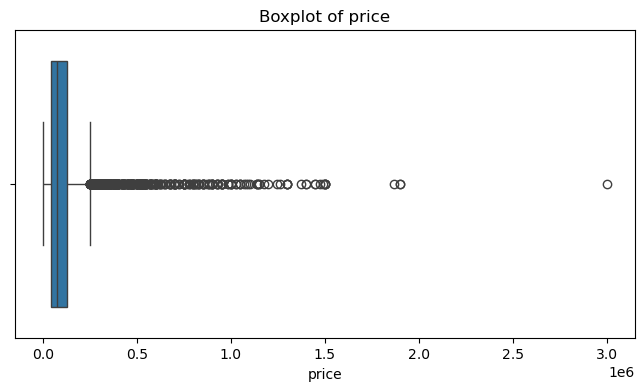

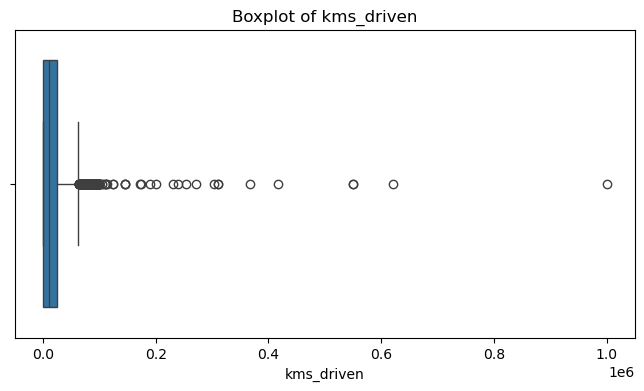

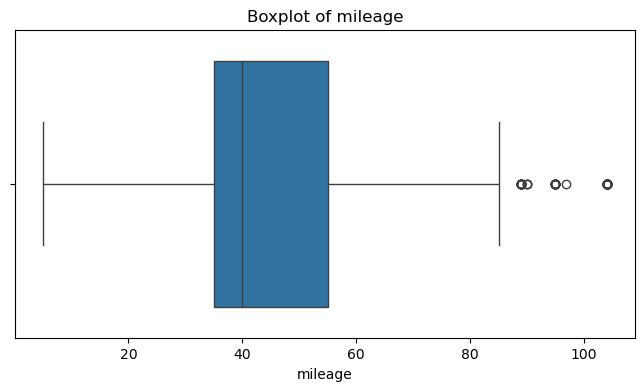

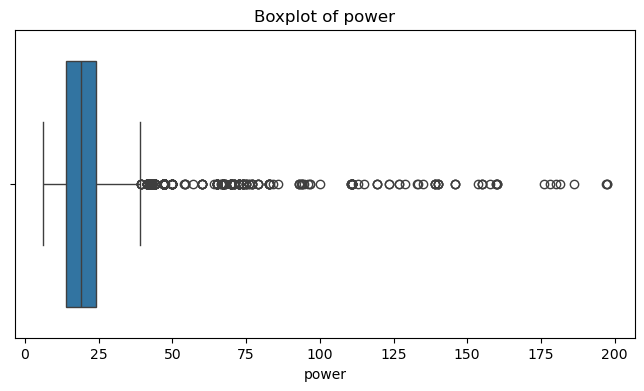

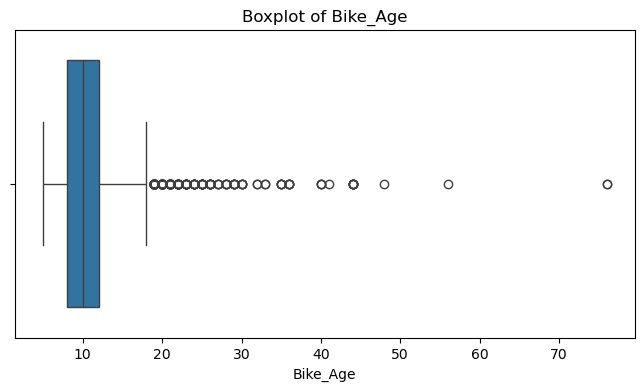

In [31]:
# Creating boxplots to identify potential outliers

numerical_features = [
    'price',
    'kms_driven',
    'mileage',
    'power',
    'Bike_Age'
]

for column in numerical_features:
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(x=df_fe[column])
    
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    
    plt.show()

In [32]:
# Detecting outliers using the IQR method

for column in numerical_features:
    
    Q1 = df_fe[column].quantile(0.25)
    Q3 = df_fe[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_fe[
        (df_fe[column] < lower_bound) |
        (df_fe[column] > upper_bound)
    ]
    
    print(f'{column}: {len(outliers)} outliers')

price: 437 outliers
kms_driven: 284 outliers
mileage: 101 outliers
power: 544 outliers
Bike_Age: 293 outliers


In [33]:
# Displaying the most expensive bikes

df_fe.nlargest(10, 'price')[
    ['model_name', 'model_year', 'kms_driven', 'power', 'price']
]
# Displaying bikes with the highest kilometers driven

df_fe.nlargest(10, 'kms_driven')[
    ['model_name', 'model_year', 'kms_driven', 'price']
]
# Displaying bikes with the highest engine power

df_fe.nlargest(10, 'power')[
    ['model_name', 'power', 'price']
]
# Checking the shape of the dataset after cleaning and feature engineering

df_fe.shape
# Displaying the first five rows of the updated dataset

df_fe.head()

,model_name,model_year,kms_driven,owner,location,mileage,power,price,Bike_Age,Age_Category,Price_Per_KM,Usage_Category
0,Bajaj Avenger Cruise 220 2017,2017,17000.0,first owner,hyderabad,35.0,19.0,63500,9,Old,3.735294,Low Usage
1,Royal Enfield Classic 350cc 2016,2016,50000.0,first owner,hyderabad,35.0,19.8,115000,10,Old,2.300000,Moderate Usage
2,Hyosung GT250R 2012,2012,14795.0,first owner,hyderabad,30.0,28.0,300000,14,Very Old,20.277121,Low Usage
3,Bajaj Dominar 400 ABS 2017,2017,28.0,first owner,pondicherry,28.0,34.5,100000,9,Old,3571.428571,Low Usage
4,Jawa Perak 330cc 2020,2020,2000.0,first owner,bangalore,40.0,30.0,197500,6,Moderate,98.750000,Low Usage


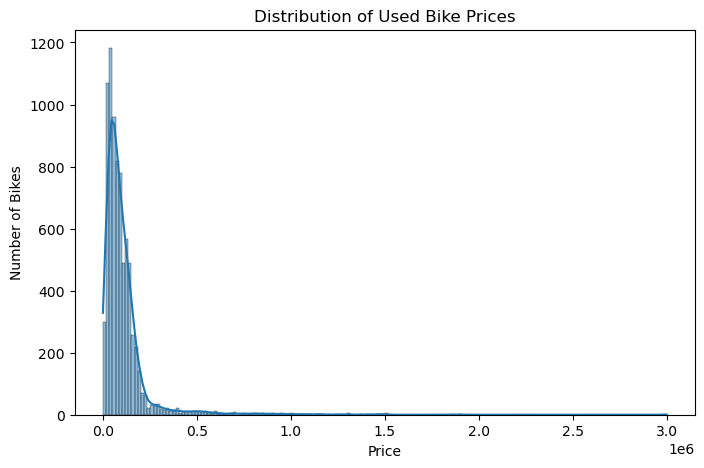

In [34]:
# Plotting the distribution of bike prices

plt.figure(figsize=(8, 5))

sns.histplot(df_fe['price'], kde=True)

plt.title('Distribution of Used Bike Prices')
plt.xlabel('Price')
plt.ylabel('Number of Bikes')

plt.show()

In [35]:
# Displaying statistical summary of bike prices

df_fe['price'].describe()

count    7.857000e+03
mean     1.067913e+05
std      1.389261e+05
min      0.000000e+00
25%      4.200000e+04
50%      7.500000e+04
75%      1.250000e+05
max      3.000000e+06
Name: price, dtype: float64

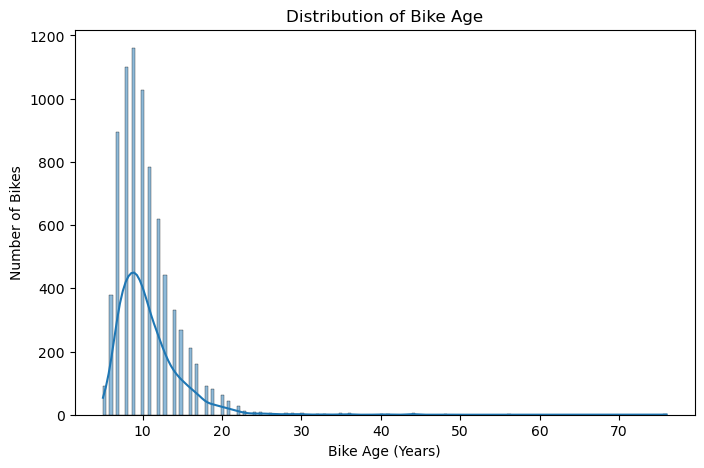

In [36]:
# Plotting the distribution of bike age

plt.figure(figsize=(8, 5))

sns.histplot(df_fe['Bike_Age'], kde=True)

plt.title('Distribution of Bike Age')
plt.xlabel('Bike Age (Years)')
plt.ylabel('Number of Bikes')

plt.show()

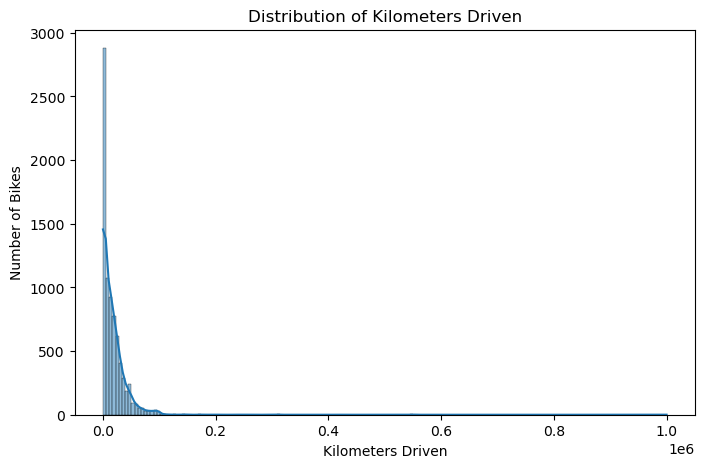

In [37]:
# Plotting the distribution of kilometers driven

plt.figure(figsize=(8, 5))

sns.histplot(df_fe['kms_driven'], kde=True)

plt.title('Distribution of Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Number of Bikes')

plt.show()

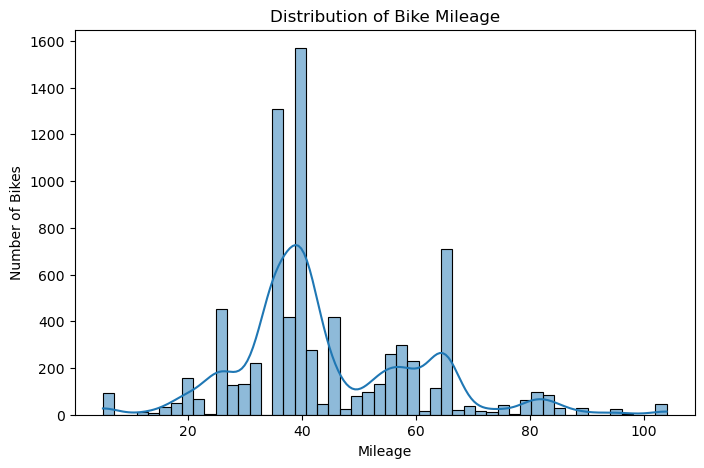

In [38]:
# Plotting the distribution of bike mileage

plt.figure(figsize=(8, 5))

sns.histplot(df_fe['mileage'], kde=True)

plt.title('Distribution of Bike Mileage')
plt.xlabel('Mileage')
plt.ylabel('Number of Bikes')

plt.show()

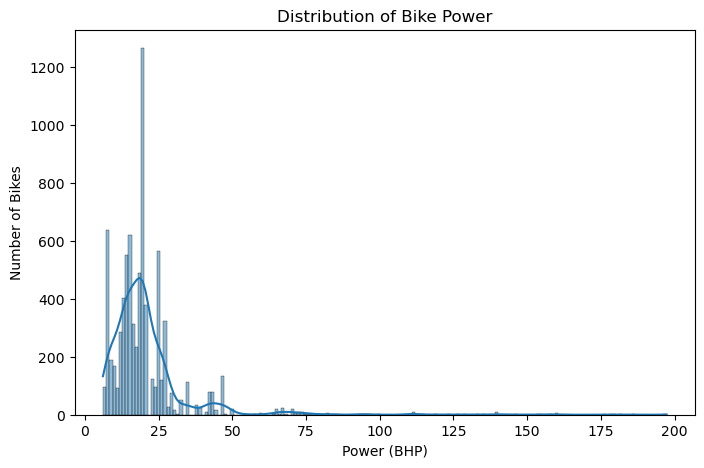

In [39]:
# Plotting the distribution of bike power

plt.figure(figsize=(8, 5))

sns.histplot(df_fe['power'], kde=True)

plt.title('Distribution of Bike Power')
plt.xlabel('Power (BHP)')
plt.ylabel('Number of Bikes')

plt.show()

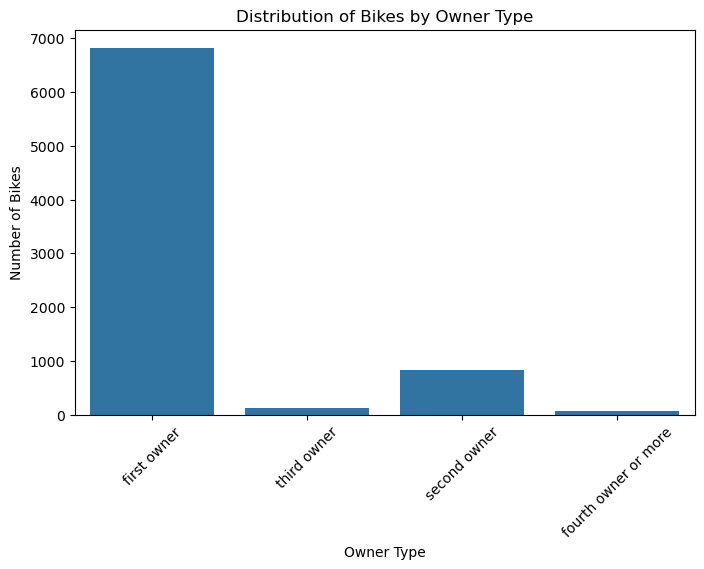

In [40]:
# Counting bikes based on ownership type

df_fe['owner'].value_counts()
# Visualizing the distribution of bikes by owner type

plt.figure(figsize=(8, 5))

sns.countplot(x='owner', data=df_fe)

plt.title('Distribution of Bikes by Owner Type')
plt.xlabel('Owner Type')
plt.ylabel('Number of Bikes')

plt.xticks(rotation=45)

plt.show()

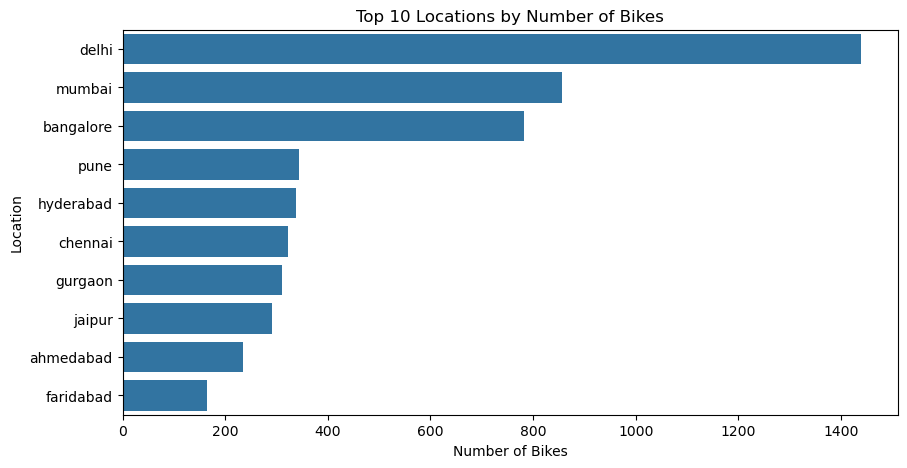

In [41]:
# Finding the top 10 locations with the highest number of bikes

top_locations = df_fe['location'].value_counts().head(10)

top_locations
# Visualizing the top 10 locations by number of bikes

plt.figure(figsize=(10, 5))

sns.barplot(
    x=top_locations.values,
    y=top_locations.index
)

plt.title('Top 10 Locations by Number of Bikes')
plt.xlabel('Number of Bikes')
plt.ylabel('Location')

plt.show()

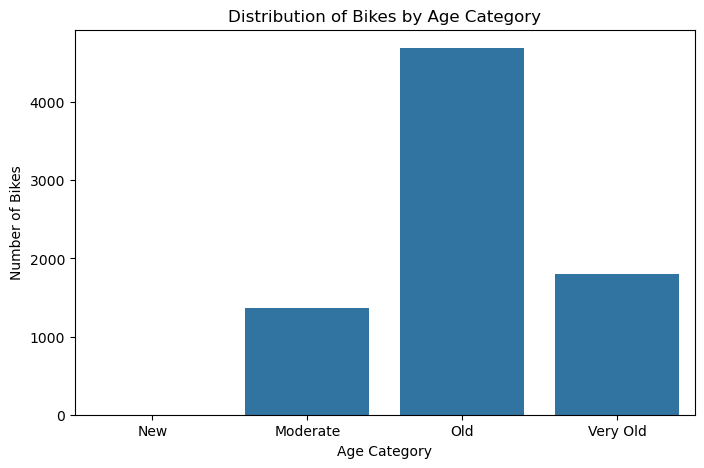

In [42]:
# Counting bikes in each age category

df_fe['Age_Category'].value_counts()
# Visualizing the distribution of bikes by age category

plt.figure(figsize=(8, 5))

sns.countplot(
    x='Age_Category',
    data=df_fe,
    order=['New', 'Moderate', 'Old', 'Very Old']
)

plt.title('Distribution of Bikes by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Number of Bikes')

plt.show()

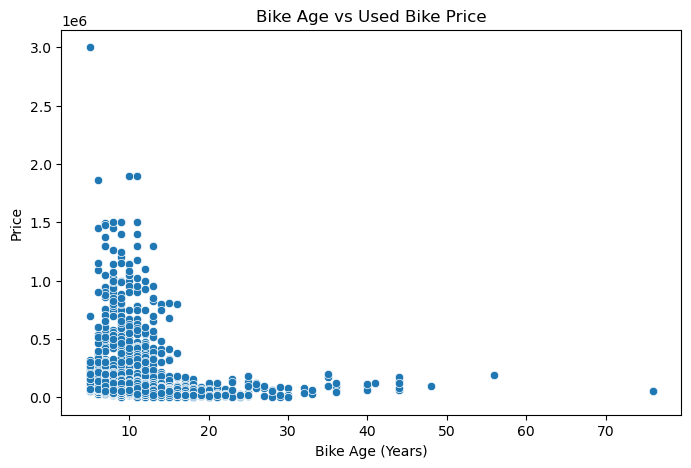

In [43]:
# Analyzing the relationship between bike age and price

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='Bike_Age',
    y='price',
    data=df_fe
)

plt.title('Bike Age vs Used Bike Price')
plt.xlabel('Bike Age (Years)')
plt.ylabel('Price')

plt.show()

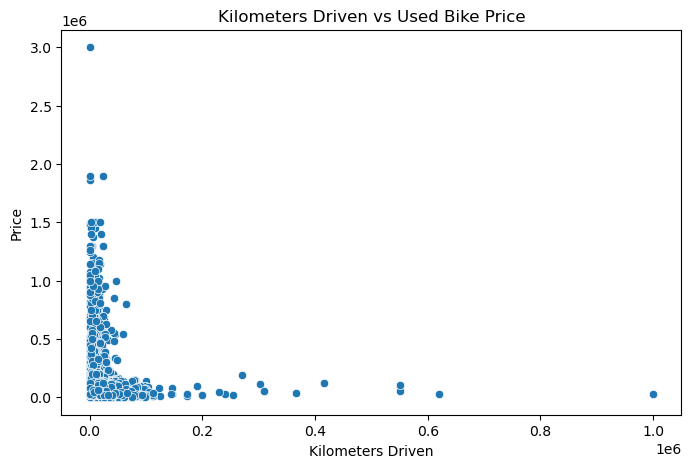

In [44]:
# Analyzing the relationship between kilometers driven and price

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='kms_driven',
    y='price',
    data=df_fe
)

plt.title('Kilometers Driven vs Used Bike Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Price')

plt.show()

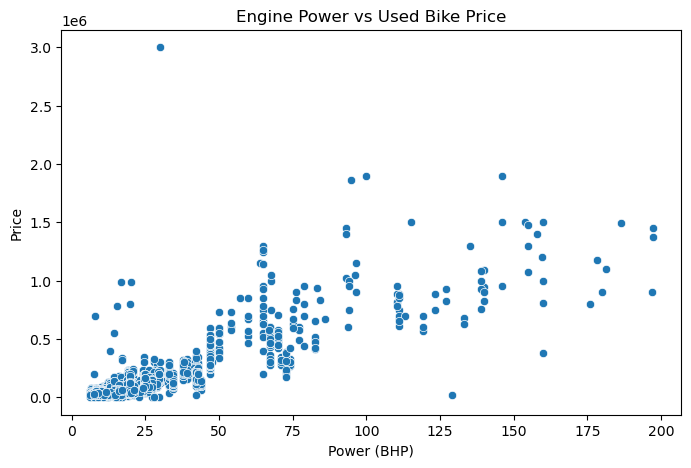

In [45]:
# Analyzing the relationship between engine power and price

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='power',
    y='price',
    data=df_fe
)

plt.title('Engine Power vs Used Bike Price')
plt.xlabel('Power (BHP)')
plt.ylabel('Price')

plt.show()

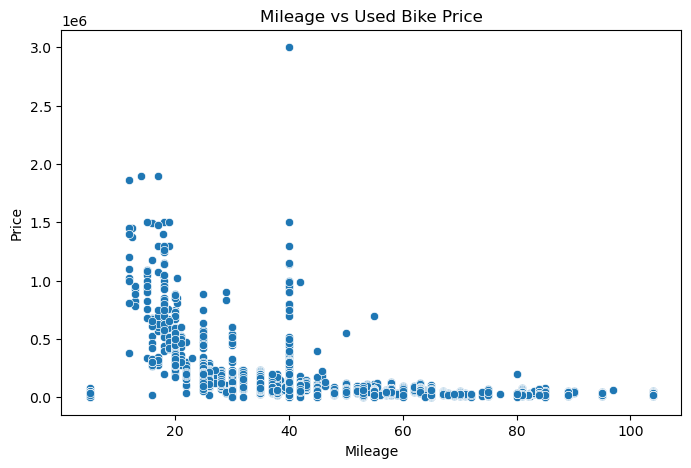

In [46]:
# Analyzing the relationship between mileage and price

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='mileage',
    y='price',
    data=df_fe
)

plt.title('Mileage vs Used Bike Price')
plt.xlabel('Mileage')
plt.ylabel('Price')

plt.show()

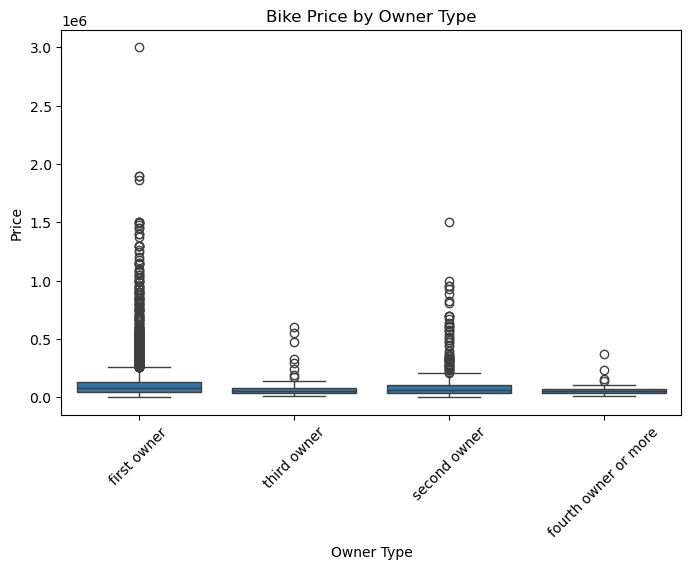

In [47]:
# Comparing bike prices across different owner types

plt.figure(figsize=(8, 5))

sns.boxplot(
    x='owner',
    y='price',
    data=df_fe
)

plt.title('Bike Price by Owner Type')
plt.xlabel('Owner Type')
plt.ylabel('Price')

plt.xticks(rotation=45)

plt.show()

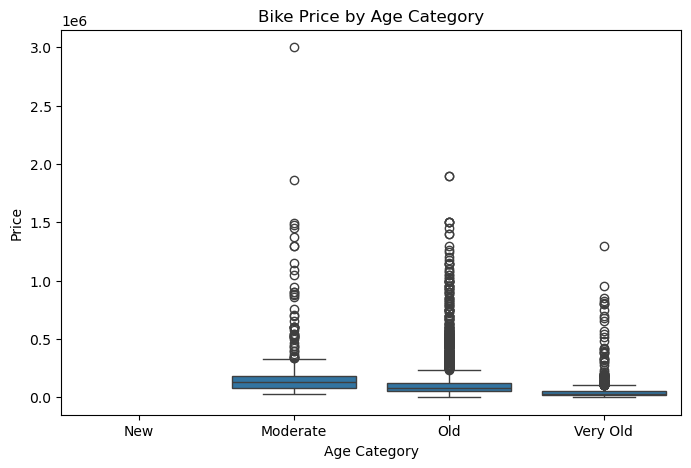

In [48]:
# Comparing bike prices across different age categories

plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Age_Category',
    y='price',
    data=df_fe,
    order=['New', 'Moderate', 'Old', 'Very Old']
)

plt.title('Bike Price by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Price')

plt.show()

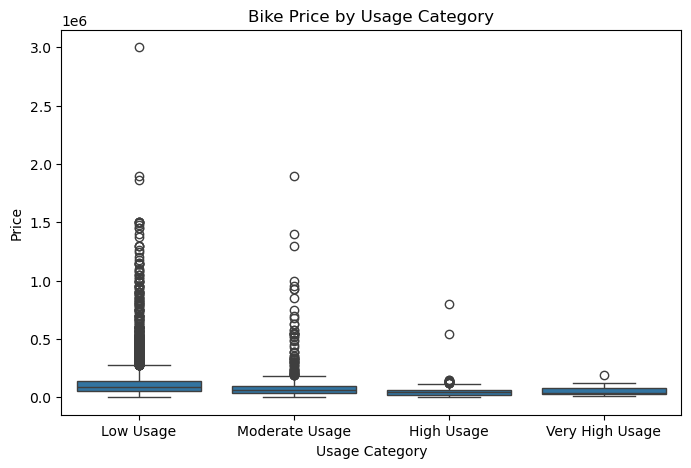

In [49]:
# Comparing bike prices across different usage categories

plt.figure(figsize=(8, 5))

sns.boxplot(
    x='Usage_Category',
    y='price',
    data=df_fe,
    order=['Low Usage', 'Moderate Usage', 'High Usage', 'Very High Usage']
)

plt.title('Bike Price by Usage Category')
plt.xlabel('Usage Category')
plt.ylabel('Price')

plt.show()

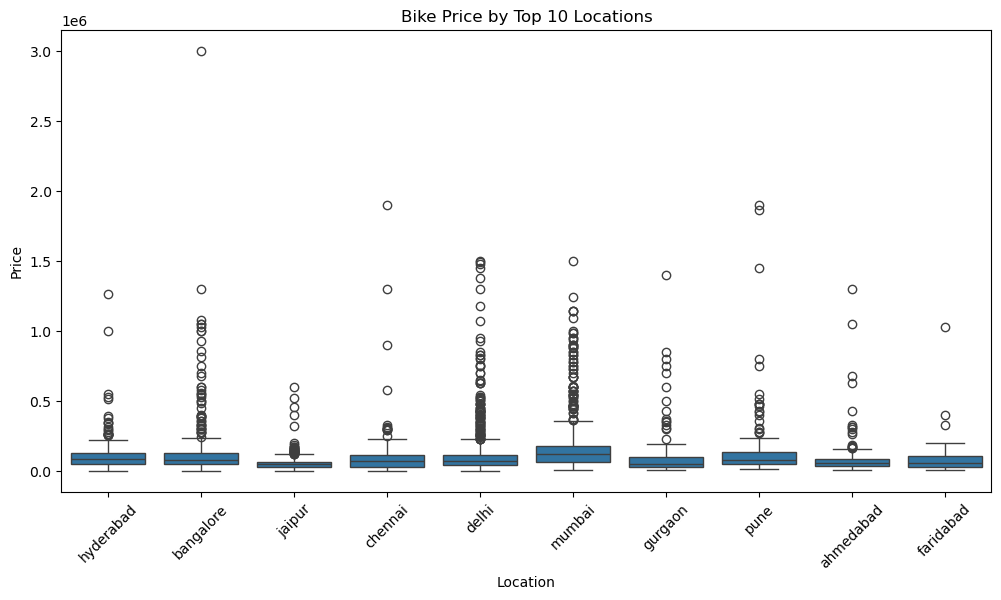

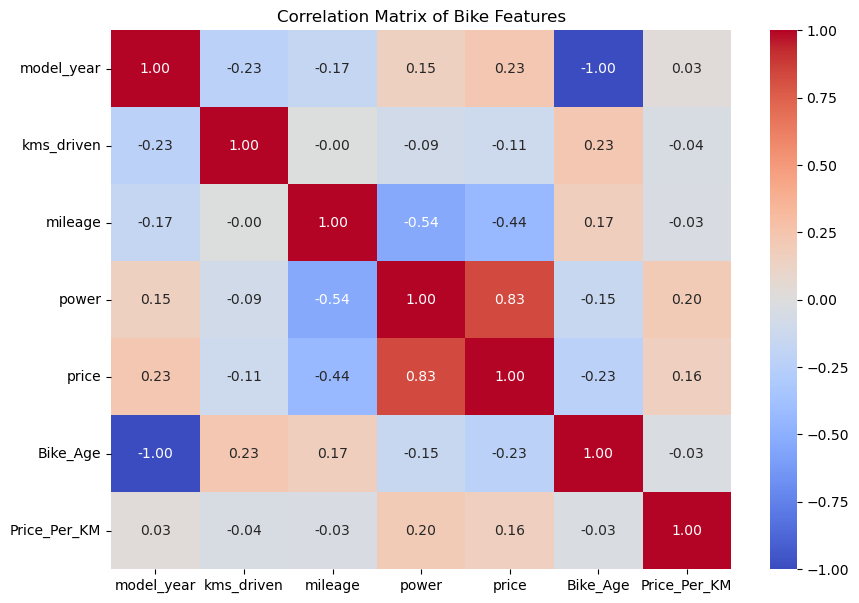

In [50]:
# Selecting the top 10 locations based on number of bikes

top_10_locations = df_fe['location'].value_counts().head(10).index

location_data = df_fe[
    df_fe['location'].isin(top_10_locations)
]
# Comparing bike prices across the top 10 locations

plt.figure(figsize=(12, 6))

sns.boxplot(
    x='location',
    y='price',
    data=location_data
)

plt.title('Bike Price by Top 10 Locations')
plt.xlabel('Location')
plt.ylabel('Price')

plt.xticks(rotation=45)

plt.show()
# Selecting numerical columns for correlation analysis

correlation_data = df_fe[
    ['model_year', 'kms_driven', 'mileage', 'power',
     'price', 'Bike_Age', 'Price_Per_KM']
]

correlation_matrix = correlation_data.corr()

correlation_matrix
# Visualizing correlations between numerical features

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Bike Features')

plt.show()

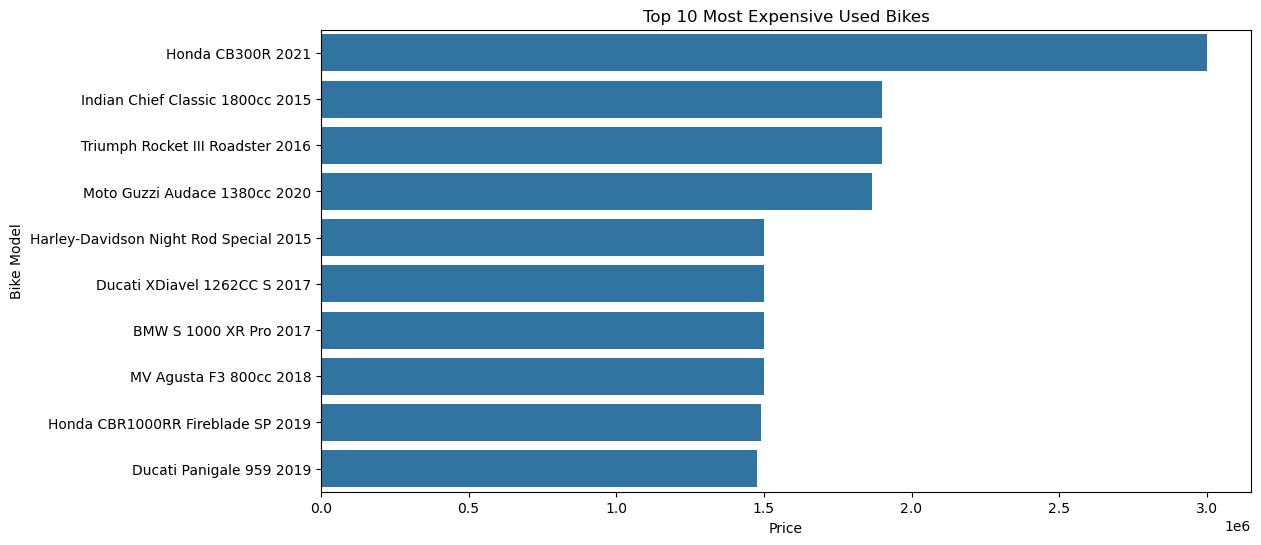

In [51]:
# Finding the 10 most expensive bikes

top_expensive_bikes = df_fe.nlargest(10, 'price')

top_expensive_bikes[
    ['model_name', 'model_year', 'kms_driven', 'power', 'price']
]
# Visualizing the 10 most expensive bikes

plt.figure(figsize=(12, 6))

sns.barplot(
    x='price',
    y='model_name',
    data=top_expensive_bikes
)

plt.title('Top 10 Most Expensive Used Bikes')
plt.xlabel('Price')
plt.ylabel('Bike Model')

plt.show()

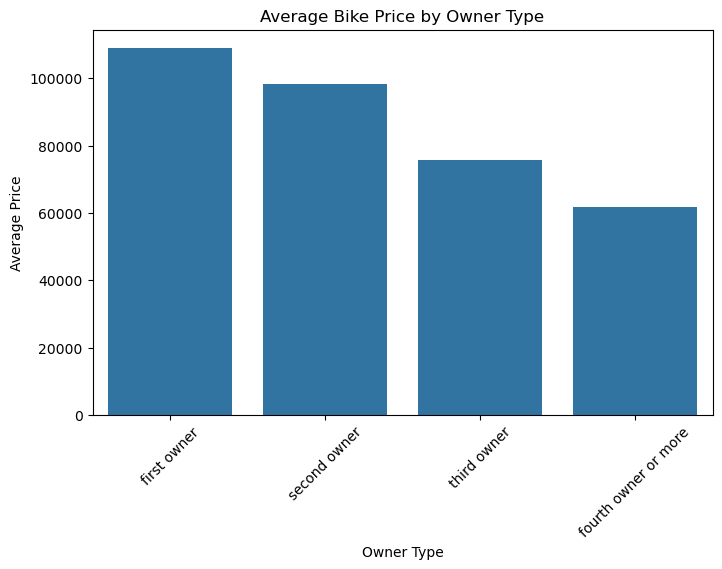

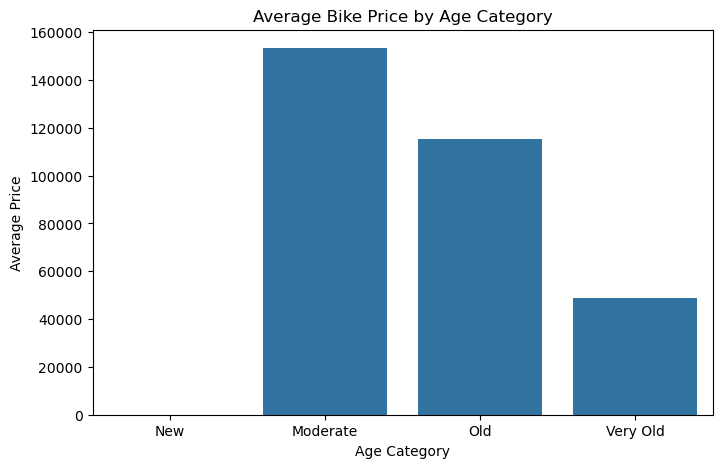

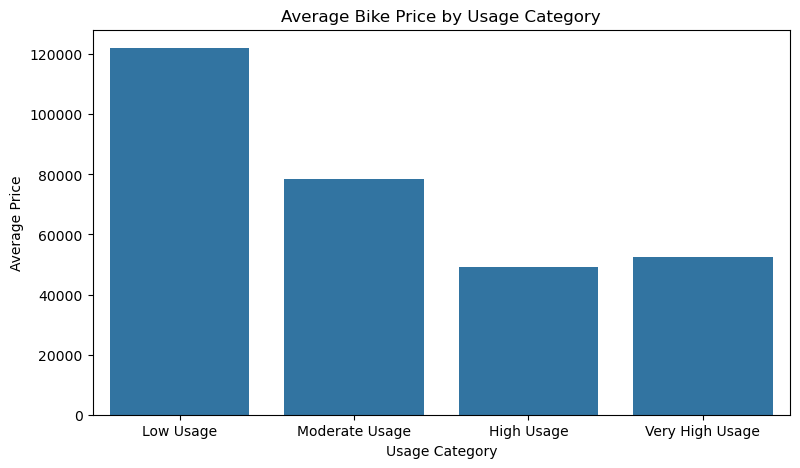

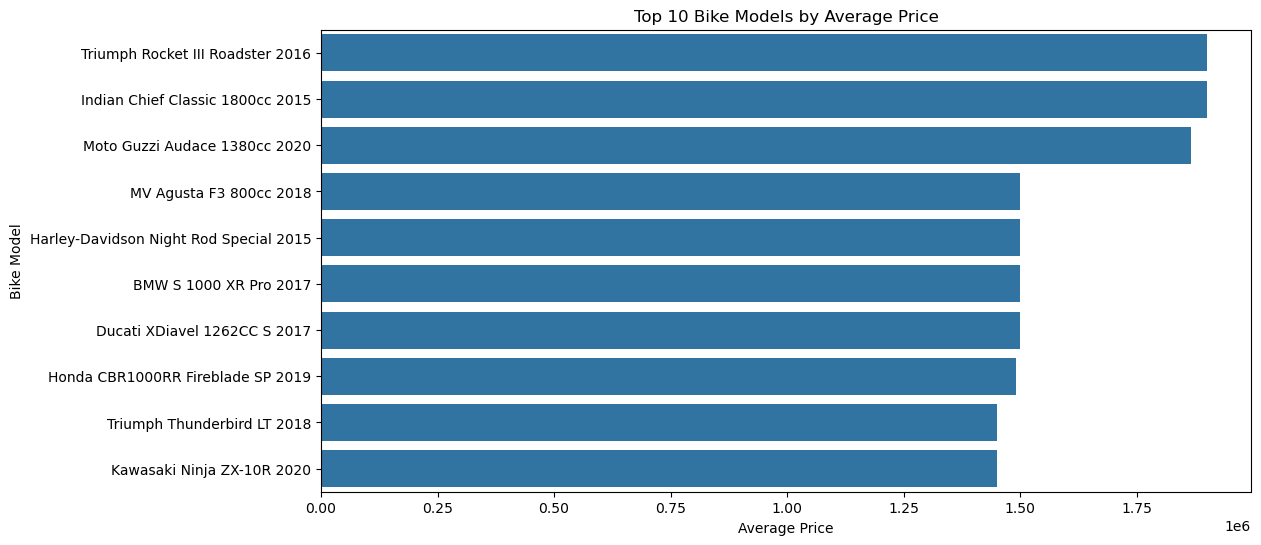

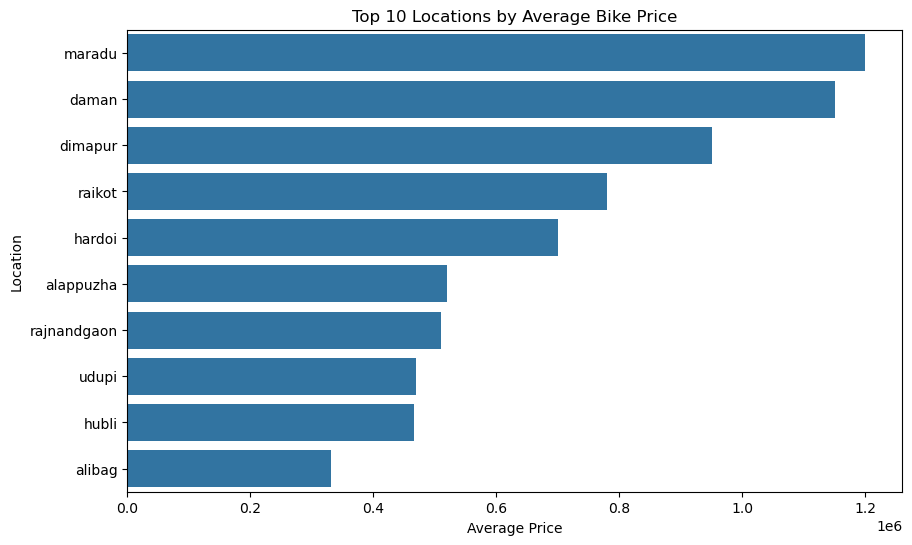

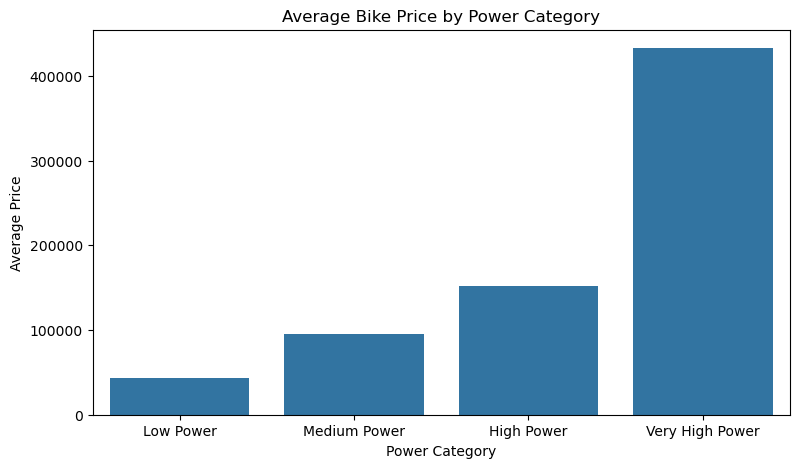

In [52]:
# Calculating the average bike price for each owner type

owner_price = df_fe.groupby('owner')['price'].mean().sort_values(ascending=False)

owner_price
# Visualizing average bike price by owner type

plt.figure(figsize=(8, 5))

sns.barplot(
    x=owner_price.index,
    y=owner_price.values
)

plt.title('Average Bike Price by Owner Type')
plt.xlabel('Owner Type')
plt.ylabel('Average Price')

plt.xticks(rotation=45)

plt.show()
# Calculating average price for each bike age category

age_price = df_fe.groupby(
    'Age_Category',
    observed=True
)['price'].mean()

age_price
# Visualizing average bike price by age category

plt.figure(figsize=(8, 5))

sns.barplot(
    x=age_price.index,
    y=age_price.values
)

plt.title('Average Bike Price by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Average Price')

plt.show()
# Calculating average price for each usage category

usage_price = df_fe.groupby(
    'Usage_Category',
    observed=True
)['price'].mean()

usage_price
# Visualizing average bike price by usage category

plt.figure(figsize=(9, 5))

sns.barplot(
    x=usage_price.index,
    y=usage_price.values
)

plt.title('Average Bike Price by Usage Category')
plt.xlabel('Usage Category')
plt.ylabel('Average Price')

plt.show()
# Calculating the average price for each bike model

model_price = (
    df_fe.groupby('model_name')['price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

model_price
# Visualizing the top 10 bike models by average price

plt.figure(figsize=(12, 6))

sns.barplot(
    x=model_price.values,
    y=model_price.index
)

plt.title('Top 10 Bike Models by Average Price')
plt.xlabel('Average Price')
plt.ylabel('Bike Model')

plt.show()
# Calculating average bike price for each location

location_price = (
    df_fe.groupby('location')['price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

location_price
# Visualizing the top 10 locations by average bike price

plt.figure(figsize=(10, 6))

sns.barplot(
    x=location_price.values,
    y=location_price.index
)

plt.title('Top 10 Locations by Average Bike Price')
plt.xlabel('Average Price')
plt.ylabel('Location')

plt.show()
# Creating categories based on engine power

df_fe['Power_Category'] = pd.cut(
    df_fe['power'],
    bins=[-np.inf, 15, 25, 40, np.inf],
    labels=['Low Power', 'Medium Power', 'High Power', 'Very High Power']
)

# Displaying power and power category

df_fe[['power', 'Power_Category']].head()
# Counting bikes in each power category

df_fe['Power_Category'].value_counts()
# Calculating average price for each power category

power_price = df_fe.groupby(
    'Power_Category',
    observed=True
)['price'].mean()

power_price
# Visualizing average price by power category

plt.figure(figsize=(9, 5))

sns.barplot(
    x=power_price.index,
    y=power_price.values
)

plt.title('Average Bike Price by Power Category')
plt.xlabel('Power Category')
plt.ylabel('Average Price')

plt.show()

In [53]:
# Finding the correlation of numerical features with bike price

price_correlation = (
    df_fe[
        ['model_year', 'kms_driven', 'mileage', 'power', 'price', 'Bike_Age']
    ]
    .corr()['price']
    .sort_values(ascending=False)
)

price_correlation

price         1.000000
power         0.832260
model_year    0.227963
kms_driven   -0.114032
Bike_Age     -0.227963
mileage      -0.437145
Name: price, dtype: float64

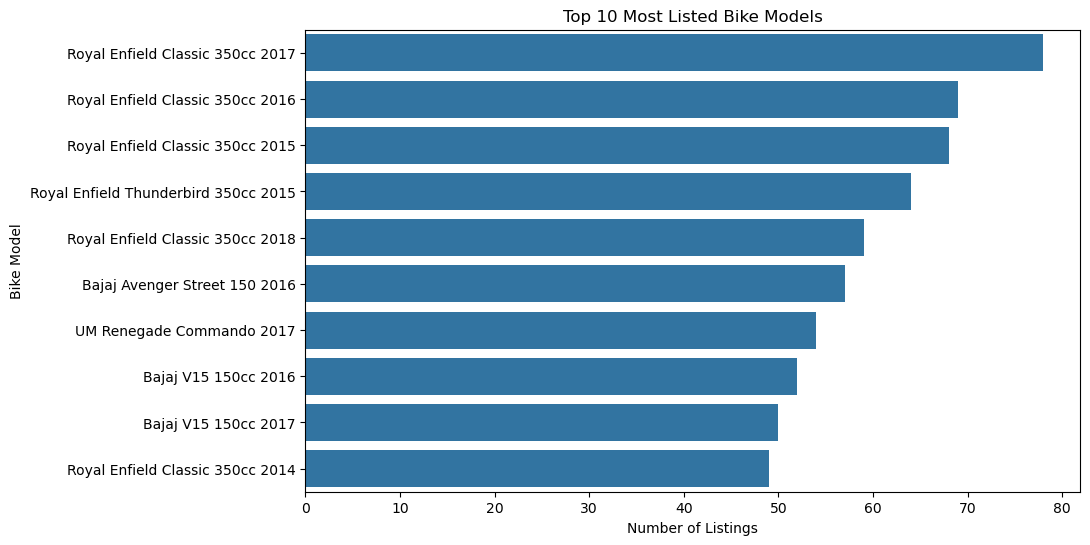

Average Used Bike Price: 106791.33689703449


In [54]:
# Finding the highest and lowest average price among age categories

age_price.sort_values(ascending=False)
# Finding the highest and lowest average price among usage categories

usage_price.sort_values(ascending=False)
# Finding the highest and lowest average price among power categories

power_price.sort_values(ascending=False)
# Finding the 10 most frequently listed bike models

top_models = df_fe['model_name'].value_counts().head(10)

top_models
# Visualizing the 10 most frequently listed bike models

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_models.values,
    y=top_models.index
)

plt.title('Top 10 Most Listed Bike Models')
plt.xlabel('Number of Listings')
plt.ylabel('Bike Model')

plt.show()
# Calculating the overall average used bike price

average_price = df_fe['price'].mean()

print("Average Used Bike Price:", average_price)
# Finding the cheapest bike

cheapest_bike = df_fe.loc[df_fe['price'].idxmin()]

cheapest_bike
# Finding the most expensive bike

most_expensive_bike = df_fe.loc[df_fe['price'].idxmax()]

most_expensive_bike
# Checking the final dataset dimensions

df_fe.shape
# Displaying all columns in the final dataset

df_fe.columns.tolist()
# Checking remaining missing values in the final dataset

df_fe.isnull().sum()
# Checking for duplicate rows in the final dataset

df_fe.duplicated().sum()
# Displaying the first 10 rows of the final dataset

df_fe.head(10)
# Saving the cleaned and feature-engineered dataset

df_fe.to_csv('used_bike_prices_feature_engineered.csv', index=False)

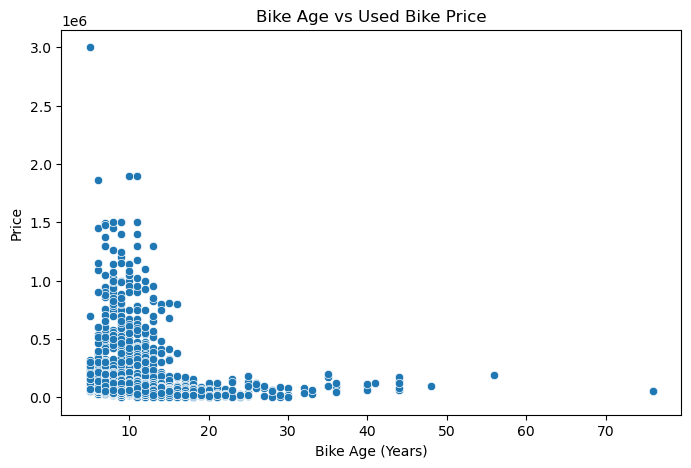

In [55]:
# Visualizing the relationship between bike age and price

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='Bike_Age',
    y='price',
    data=df_fe
)

plt.title('Bike Age vs Used Bike Price')
plt.xlabel('Bike Age (Years)')
plt.ylabel('Price')

plt.show()

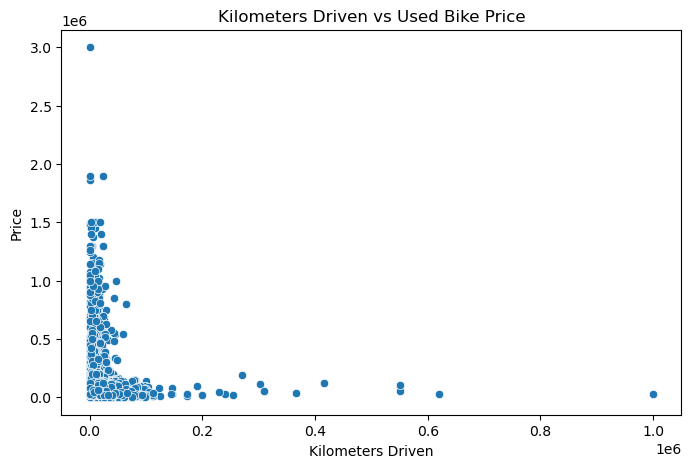

In [56]:
# Visualizing the relationship between kilometers driven and price

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='kms_driven',
    y='price',
    data=df_fe
)

plt.title('Kilometers Driven vs Used Bike Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Price')

plt.show()

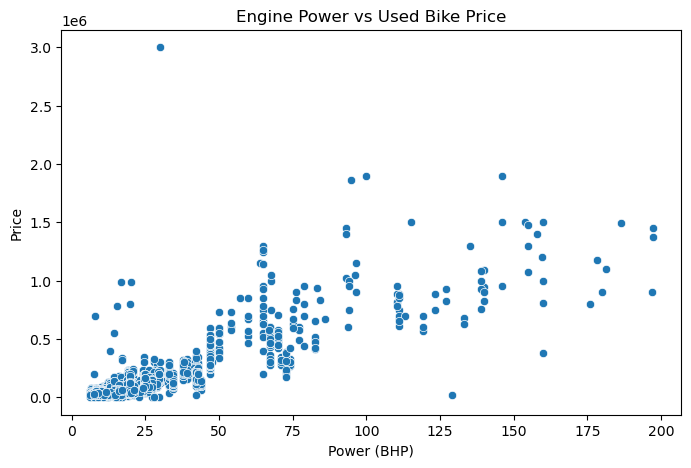

In [57]:
# Visualizing the relationship between engine power and price

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x='power',
    y='price',
    data=df_fe
)

plt.title('Engine Power vs Used Bike Price')
plt.xlabel('Power (BHP)')
plt.ylabel('Price')

plt.show()

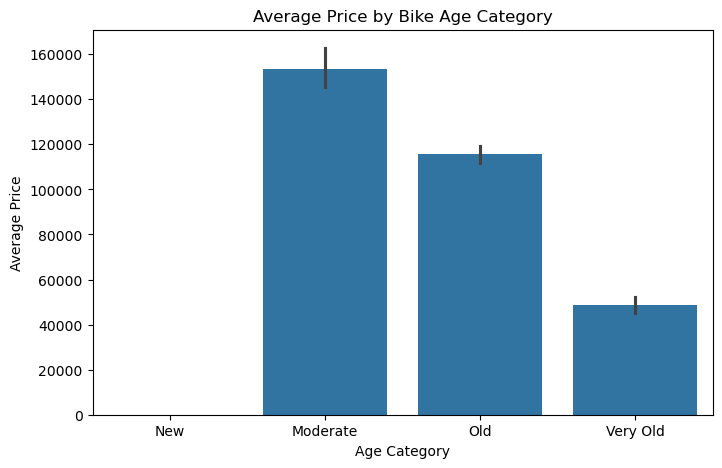

In [58]:
# Comparing average bike prices across age categories

plt.figure(figsize=(8, 5))

sns.barplot(
    x='Age_Category',
    y='price',
    data=df_fe,
    order=['New', 'Moderate', 'Old', 'Very Old'],
    estimator='mean'
)

plt.title('Average Price by Bike Age Category')
plt.xlabel('Age Category')
plt.ylabel('Average Price')

plt.show()

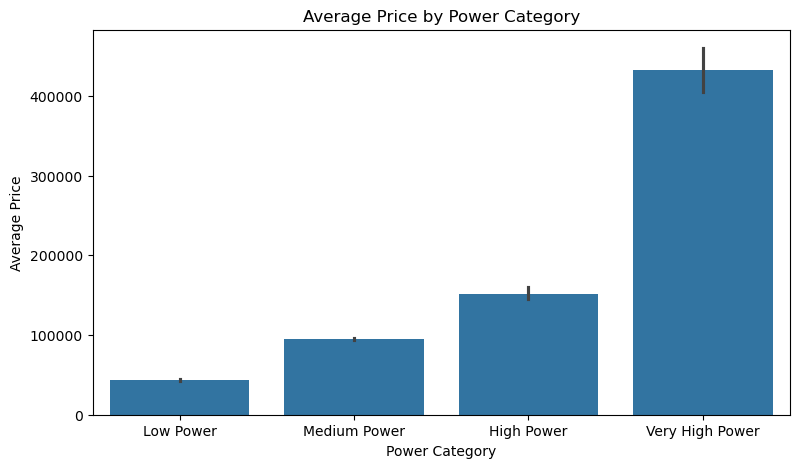

In [59]:
# Comparing average bike prices across power categories

plt.figure(figsize=(9, 5))

sns.barplot(
    x='Power_Category',
    y='price',
    data=df_fe,
    estimator='mean'
)

plt.title('Average Price by Power Category')
plt.xlabel('Power Category')
plt.ylabel('Average Price')

plt.show()

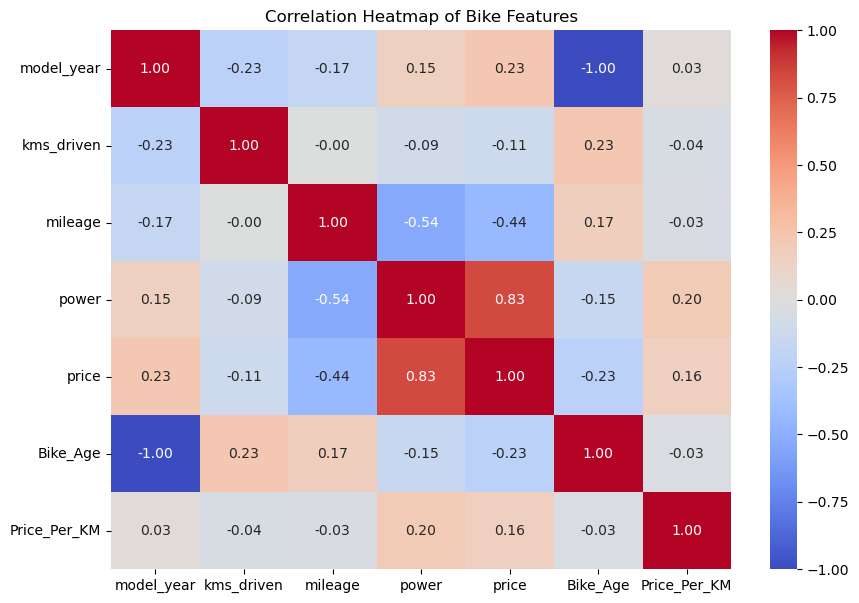

In [60]:
# Creating a correlation heatmap for numerical features

plt.figure(figsize=(10, 7))

correlation_matrix = df_fe[
    [
        'model_year',
        'kms_driven',
        'mileage',
        'power',
        'price',
        'Bike_Age',
        'Price_Per_KM'
    ]
].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Bike Features')

plt.show()

In [ ]:
## Conclusion

This project analyzed used bike prices using exploratory data analysis and feature engineering.

The dataset was cleaned by handling inconsistent numerical values, missing values, and duplicate records. New features such as Bike Age, Age Category, Price Per KM, Usage Category, and Power Category were created to improve the analysis.

The analysis explored how bike age, kilometers driven, mileage, engine power, ownership, location, and other factors are associated with used bike prices.

The correlation analysis and visualizations helped identify the major factors associated with price and provided useful insights into the used-bike market.